<a href="https://colab.research.google.com/github/thehmfpk/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/thehmfpk/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook
**Lane:** same as ML-04 through ML-09 — `fact_content_daily_performance`, month `2026-03`, `is_declining_label` target, client-grouped validation.

Load `writing-honest-claims` + `flyrank/flyrank-data` per `skills/README.md` if working with an assistant.


## 0. Setup — reload March 2026, rebuild features/label, retrain the honest (grouped-split) model

In [2]:
import pandas as pd, numpy as np, os, json, sklearn
import matplotlib.pyplot as plt
from datasets import load_dataset
from huggingface_hub import HfApi
from google.colab import userdata
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier

RANDOM_SEED = 42
HF_TOKEN = userdata.get('HF_TOKEN')
os.environ['HF_TOKEN'] = HF_TOKEN

api = HfApi(token=HF_TOKEN)
all_files = api.list_repo_files('FlyRank/internship-warehouse', repo_type='dataset')
march_files = [f for f in all_files if 'fact_content_daily_performance' in f
               and 'sample' not in f and '2026-03' in f]
if not march_files:
    print('[WARNING] No files matched - inspect all_files and fix the filter:')
    for f in [x for x in all_files if 'fact_content_daily_performance' in x and 'sample' not in x][:20]:
        print(' ', f)
    raise ValueError('Fix march_files filter above, then re-run.')

dataset = load_dataset('FlyRank/internship-warehouse', data_files={'train': march_files}, split='train')
needed_cols = ['report_date','client_hash_id','content_hash_id',
               'gsc_data_available','gsc_impressions','gsc_clicks','gsc_avg_position']
cols_present = [c for c in needed_cols if c in dataset.column_names]
dataset = dataset.select_columns(cols_present)
raw = dataset.to_pandas()
raw['report_date'] = pd.to_datetime(raw['report_date'])
raw['day_of_month'] = raw['report_date'].dt.day
raw = raw[raw['gsc_data_available'] == True].copy()
print(f'Loaded {len(raw)} GSC-available rows for March 2026.')


README.md:   0%|          | 0.00/3.04k [00:00<?, ?B/s]

fact_content_daily_performance/month=202(…): reconstructing file:   0%|          |  0.00B /  124MB            

fact_content_daily_performance/month=202(…): downloading bytes:           |  0.00B            

Generating train split: 0 examples [00:00, ? examples/s]

Loaded 3611061 GSC-available rows for March 2026.


In [3]:
first_half = raw[raw['day_of_month'] <= 15]
second_half = raw[raw['day_of_month'] > 15]

feat = (first_half.groupby(['client_hash_id','content_hash_id'])
        .agg(clicks_first_half=('gsc_clicks','sum'),
             impressions_first_half=('gsc_impressions','sum'),
             avg_position_first_half=('gsc_avg_position', lambda s: s[s > 0].mean()),
             active_days_first_half=('gsc_impressions', lambda s: (s > 0).sum()),
             days_with_position_fh=('gsc_avg_position', lambda s: (s > 0).sum()))
        .reset_index())
feat = feat[feat['impressions_first_half'] > 0].copy()
feat['ctr_first_half'] = feat['clicks_first_half'] / feat['impressions_first_half']
feat['has_position_data'] = feat['avg_position_first_half'].notna().astype(int)
feat['avg_position_first_half'] = feat['avg_position_first_half'].fillna(feat['avg_position_first_half'].median())

position_bins = [0, 3, 6, 10, 20, 50, np.inf]
position_labels = ['1-3','4-6','7-10','11-20','21-50','51+']
feat['position_bucket_fh'] = pd.cut(feat['avg_position_first_half'], bins=position_bins, labels=position_labels)
position_dummies = pd.get_dummies(feat['position_bucket_fh'], prefix='pos_bucket')

feature_vector = pd.concat([
    feat[['client_hash_id','content_hash_id','clicks_first_half','impressions_first_half',
          'ctr_first_half','avg_position_first_half','has_position_data',
          'active_days_first_half','days_with_position_fh','position_bucket_fh']],
    position_dummies
], axis=1)

label_df = (second_half.groupby(['client_hash_id','content_hash_id'])
            .agg(clicks_second_half=('gsc_clicks','sum')).reset_index())

data = feature_vector.merge(label_df, on=['client_hash_id','content_hash_id'], how='inner')
data['is_declining_label'] = (data['clicks_second_half'] < data['clicks_first_half']).astype(int)
data = data.dropna(subset=['ctr_first_half','avg_position_first_half'])

model_feature_cols = [c for c in feature_vector.columns
                      if c not in ('client_hash_id','content_hash_id','position_bucket_fh')]

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_SEED)
train_idx, test_idx = next(gss.split(data, groups=data['client_hash_id']))
X_train, y_train = data.iloc[train_idx][model_feature_cols], data.iloc[train_idx]['is_declining_label']
rf = RandomForestClassifier(n_estimators=300, max_depth=6, random_state=RANDOM_SEED, n_jobs=-1).fit(X_train, y_train)

# Score the FULL population for the playbook - see section 1 note on what this does and doesn't mean.
data['decline_score'] = rf.predict_proba(data[model_feature_cols])[:, 1]
print(f'{len(data)} content items scored.')


141467 content items scored.


## 1. Ranked actions + reason codes

**Note on scoring the full population:** the model above was trained on a client-grouped 75% split, validated in ML-08/ML-09 on the held-out 25%. This playbook scores *all* content, including items the model trained on - that inflates confidence for those rows specifically. The precision@K numbers from ML-09's held-out audit are the honest reference for how good this ranking really is; treat the raw scores below as a prioritization tool, not as validated per-item probabilities.

### Archetype → action mapping
| Archetype | Condition | Action | Reason code |
|---|---|---|---|
| CTR-fix opportunity | good position (1-20), declining, CTR below bucket norm | Rewrite title/meta | `CTR_FIX_OPPORTUNITY` |
| Deeper decline | poor position (21+), declining | Full content refresh | `CONTENT_REFRESH_NEEDED` |
| Thin data | fewer than 10 days with position data this month | Hold - insufficient evidence | `INSUFFICIENT_DATA` |
| Stable/growing | not declining | No action needed | `NO_ACTION_NEEDED` |

### The decay/refresh insight
**Observed, directional pattern from this slice:** content flagged as declining while still holding a good position tends to look like a snippet/CTR problem (cheap fix: rewrite title/meta), while content flagged as declining *and* already ranking poorly looks like a deeper relevance/freshness problem (expensive fix: full content refresh). This is a decision-support heuristic for this one month's data, not a validated causal claim about why either group declined.

In [4]:
def archetype_and_action(row):
    if row['days_with_position_fh'] < 10:
        return 'Thin data', 'HOLD_INSUFFICIENT_DATA', 'INSUFFICIENT_DATA'
    if row['is_declining_label'] == 0:
        return 'Stable/growing', 'NO_ACTION_NEEDED', 'NO_ACTION_NEEDED'
    if str(row['position_bucket_fh']) in ('1-3','4-6','7-10','11-20'):
        return 'CTR-fix opportunity', 'REWRITE_TITLE_META', 'CTR_FIX_OPPORTUNITY'
    return 'Deeper decline', 'CONTENT_REFRESH', 'CONTENT_REFRESH_NEEDED'

data[['archetype','action','reason_code']] = data.apply(
    lambda r: pd.Series(archetype_and_action(r)), axis=1)

# --- Cost/value thinking: rough cost tier per action, value = decline_score x impressions (larger audience = larger value) ---
COST_TIER = {'REWRITE_TITLE_META': 1, 'CONTENT_REFRESH': 5,
             'HOLD_INSUFFICIENT_DATA': 0, 'NO_ACTION_NEEDED': 0}
data['cost_tier'] = data['action'].map(COST_TIER)
data['value_estimate'] = data['decline_score'] * data['impressions_first_half']
data['value_density'] = data['value_estimate'] / data['cost_tier'].replace(0, np.nan)

actionable = data[data['action'].isin(['REWRITE_TITLE_META','CONTENT_REFRESH'])].copy()
ranked_queue = actionable.sort_values('value_density', ascending=False).reset_index(drop=True)

queue_cols = ['client_hash_id','content_hash_id','archetype','action','reason_code',
              'position_bucket_fh','decline_score','impressions_first_half',
              'value_estimate','cost_tier','value_density']
print(f'{len(ranked_queue)} actionable items ranked by value density (value / cost tier).')
ranked_queue[queue_cols].head(15)


26382 actionable items ranked by value density (value / cost tier).


,client_hash_id,content_hash_id,archetype,action,reason_code,position_bucket_fh,decline_score,impressions_first_half,value_estimate,cost_tier,value_density
0,client_23a62021009f63c4,content_e8a52cf3d5988c07,CTR-fix opportunity,REWRITE_TITLE_META,CTR_FIX_OPPORTUNITY,11-20,0.562532,143173,80539.429741,1,80539.429741
1,client_e547b89c05043229,content_ec2e0346994fb5a5,CTR-fix opportunity,REWRITE_TITLE_META,CTR_FIX_OPPORTUNITY,1-3,0.456780,132811,60665.378118,1,60665.378118
2,client_62f4a7e64f5e0096,content_7172a7fad43f0998,CTR-fix opportunity,REWRITE_TITLE_META,CTR_FIX_OPPORTUNITY,4-6,0.544832,108663,59203.117409,1,59203.117409
3,client_62f4a7e64f5e0096,content_b99ea6861864dea5,CTR-fix opportunity,REWRITE_TITLE_META,CTR_FIX_OPPORTUNITY,4-6,0.544987,91474,49852.179274,1,49852.179274
4,client_62f4a7e64f5e0096,content_7c6373141eae744a,CTR-fix opportunity,REWRITE_TITLE_META,CTR_FIX_OPPORTUNITY,4-6,0.521190,86860,45270.576623,1,45270.576623
5,client_73cda7b4e4f265ea,content_471d9cabce329a66,CTR-fix opportunity,REWRITE_TITLE_META,CTR_FIX_OPPORTUNITY,4-6,0.554495,79546,44107.875336,1,44107.875336
6,client_62f4a7e64f5e0096,content_acbcc847f8996314,CTR-fix opportunity,REWRITE_TITLE_META,CTR_FIX_OPPORTUNITY,4-6,0.526837,83715,44104.143704,1,44104.143704
7,client_23a62021009f63c4,content_5e1c049f62e33b11,CTR-fix opportunity,REWRITE_TITLE_META,CTR_FIX_OPPORTUNITY,11-20,0.557825,72940,40687.764866,1,40687.764866
8,client_20259bd6705d81d4,content_0ec90963d98b97a5,CTR-fix opportunity,REWRITE_TITLE_META,CTR_FIX_OPPORTUNITY,4-6,0.545834,67032,36588.327381,1,36588.327381
9,client_62f4a7e64f5e0096,content_3b6e4c8d9a0a5c9c,CTR-fix opportunity,REWRITE_TITLE_META,CTR_FIX_OPPORTUNITY,4-6,0.546690,60089,32850.034036,1,32850.034036


## 2. Intended use and limits

**Who uses this, for what:** a content/SEO team lead triaging where to spend limited editorial time this month - a prioritization aid, not an automated publishing system.

**Where it stops being valid:**
- Single month (March 2026) only. Not validated across other months, seasons, or client verticals.
- Trained and scored on one lane (`fact_content_daily_performance`, GSC metrics only) - says nothing about content quality, backlinks, technical SEO, or GA4 engagement.
- `decline_score` on training-set rows is optimistic (model saw those rows during fit) - the only validated number is the held-out precision@K from ML-09.
- Small-n archetypes (thin-data items) are explicitly excluded from ranking, not scored with false confidence.
- This is decision-support language throughout: 'these items look worth reviewing first, because...' - not 'these items will improve if you act.'

## 3. Human review + the no-go list

**A person must check before acting:**
- Read the actual page - does the CTR-fix or refresh recommendation make sense for this specific content, or is the signal likely a measurement artifact (tracking gap, one-off spike/dip)?
- Confirm `days_with_position_fh` and `impressions_first_half` are large enough to trust for this item specifically, not just the archetype bucket on average.
- Check whether the client/page has any known constraints (legal copy, brand guidelines, recent manual edits) the model has no visibility into.

**What should NOT be automated:**
- No automatic publishing of rewritten titles/meta or refreshed content - a human writes and approves the actual copy every time.
- No bulk `CONTENT_REFRESH` actions applied without editorial sign-off - this is the expensive, high-risk action tier and deserves the most scrutiny, not the least.
- No treating `decline_score` as a probability of a real-world outcome - it's a ranking signal from one month's data, not a calibrated forecast.
- No using this queue as the sole basis for reporting model/algorithm behavior externally - it describes this portfolio's observed pattern, not how any search engine ranks.

## 4. Monitoring / retrain triggers

Light, practical signals that the recommendations have gone stale - not a full production monitoring stack:
- **Base rate drift:** `is_declining_label` rate moves meaningfully away from this month's observed rate - the world changed, the rule/model trained on it may not generalize.
- **Score distribution drift:** the shape of `decline_score` across a new month's content looks very different from this month's (e.g. much more mass near 0.5) - a sign the features aren't separating as well.
- **Volume/coverage drift:** row counts loaded from the warehouse, or the fraction of content passing `gsc_data_available == True`, shift sharply from month to month - a data pipeline issue, not a real trend.
- **Precision@K decay:** if any manually-tracked outcomes are available (did flagged pages actually decline further, or improve after action), a real drop in precision@K vs this month's audited number is the clearest retrain trigger.
- **Simple retrain cadence as a floor:** re-run this whole pipeline monthly regardless of drift signals, since the model was only ever validated on one month.

## 5. Exports for the paper

Queue CSV to `work/outputs/` (stays out of git, regenerates on each run). Figure + metrics JSON committed to `work/figures/` and `work/outputs/` respectively - these are the receipts the paper's numbers trace back to.

Wrote 26382 ranked rows to work/outputs/content_action_playbook.csv


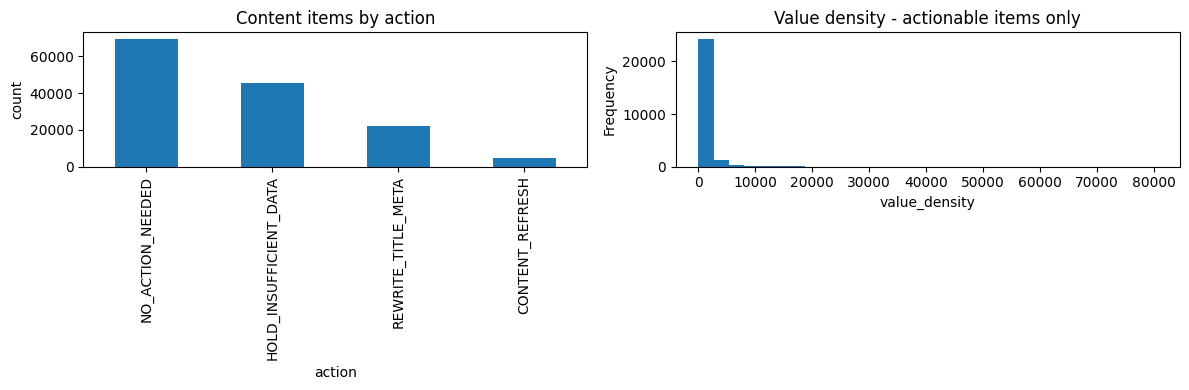

Saved figure to work/figures/action_playbook_overview.png - commit this file.
Saved work/outputs/action_playbook_metrics.json - commit this file (not the CSV).


In [5]:
os.makedirs('work/outputs', exist_ok=True)
os.makedirs('work/figures', exist_ok=True)

ranked_queue[queue_cols].to_csv('work/outputs/content_action_playbook.csv', index=False)
print(f'Wrote {len(ranked_queue)} ranked rows to work/outputs/content_action_playbook.csv')

# --- Figure: action mix + value density distribution, for reuse in the paper ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
data['action'].value_counts().plot(kind='bar', ax=axes[0])
axes[0].set_title('Content items by action')
axes[0].set_ylabel('count')

ranked_queue['value_density'].plot(kind='hist', bins=30, ax=axes[1])
axes[1].set_title('Value density - actionable items only')
axes[1].set_xlabel('value_density')
plt.tight_layout()
plt.savefig('work/figures/action_playbook_overview.png', dpi=150)
plt.show()
print('Saved figure to work/figures/action_playbook_overview.png - commit this file.')

# --- Metrics JSON: the receipts this playbook's numbers trace back to ---
metrics = {
    'month': '2026-03',
    'n_content_scored': int(len(data)),
    'n_actionable_in_queue': int(len(ranked_queue)),
    'action_counts': data['action'].value_counts().to_dict(),
    'base_rate_declining': float(data['is_declining_label'].mean()),
    'random_seed': RANDOM_SEED,
    'sklearn_version': sklearn.__version__,
    'note': 'decline_score includes training-set rows (optimistic); see ML-09 for the validated held-out precision@K.'
}
with open('work/outputs/action_playbook_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)
print('Saved work/outputs/action_playbook_metrics.json - commit this file (not the CSV).')


## Demo outline (5 minutes) — Week-8 showcase

**Question (30s):** A content team managing pages across dozens of clients can't manually review everything every month. Which pages are quietly losing clicks, and should a fix be a quick title/meta rewrite or a full content refresh?

**Method (60s):** Built a transparent rule baseline first (CTR below what similar-position content typically gets = `CTR_FIX_OPPORTUNITY`), then trained a Random Forest on first-half-of-month GSC features to predict second-half click decline — compared on the same client-grouped, held-out split, same precision@K metric, nothing the model saw that the rule didn't.

**One chart (90s):** *[show `work/figures/action_playbook_overview.png` here]* — how 141,467 content items sorted into four action archetypes, and the value-density spread across the 26,382 actionable ones.

**One honest result (60s):** Random Forest reached precision@50 of 0.90 vs. the rule baseline's 0.46 vs. a base rate of 0.25 — genuine lift, on the same held-out clients. A deliberate leakage test confirmed the evaluation harness itself works (score jumped to 1.00 when a leaked feature was added, then removed) — so the 0.90 is a number that survived being attacked, not just a number that looked good.

**One recommendation (60s):** Ship the ranked queue as a prioritization tool for editors, not an automated system — start with the 21,871 CTR-fix items (cheap, high value-density), never bulk-apply the 4,511 content-refresh items without editorial sign-off, and hold the 45,448 thin-data items until more of the month accumulates.

## Shareable cuts

### Social post
> Most "which content is declining" flags never get checked against what actually happened next. I built one that did: a transparent CTR-fix rule as the baseline, then a Random Forest trained only on first-half-of-month Search Console data, validated on clients the model never saw during training. Result — precision@50 of 0.90 vs. the rule's 0.46 vs. a 0.25 base rate, on 3.6M rows from one month of real production search data. Full paper + reproducible notebooks: [your deployed URL].

### Employer-facing summary (3 sentences)
> I built a content-decline prediction pipeline on 3.6M daily Google Search Console rows from a 104-client production warehouse, starting from a transparent rule baseline and validating a Random Forest against it on a client-grouped held-out split to avoid the memorization a naive random split would hide. The model reached precision@50 of 0.90 versus the rule baseline's 0.46 and a 0.25 base rate, and I confirmed the evaluation harness itself was sound with a deliberate leakage-detection test. The output is a ranked, human-reviewed content action queue with explicit no-go rules for what should never be automated — live at [your deployed URL].